# **Exploratory Data Analysis (EDA)**

## Objectives

* This nootbook is  to explore the cleaned Online Retail Transaction dataset and identify patterns,relationships, distribution outliers and trends that can make it useful business insights.

The analysis will be on product performance, geographical patterns, transactions, customer behaviour, and sales trends.
## Inputs

* Cleaned dataset: 'Dataset/CleanData/Online_Retail_Cleaned.csv'

## Outputs

* Descriptive statistics
* Distibution analysis
* Outlier analysis
* Correlation analysis
* Exploratory visualisations
* Business insights
* Machine learning and visualisation work
* Hypothesis and statistical analysis where need it.

## Additional Comments

* The analysis is performed from ETL cleaned dataset and it will explain the analysis step by step and highlight the main findings.



---

# Change working directory

* We are assuming you will store the notebooks in a subfolder, therefore when running the notebook in the editor, you will need to change the working directory

We need to change the working directory from its current folder to its parent folder
* We access the current directory with os.getcwd()

In [26]:
import os
current_dir = os.getcwd()
current_dir

'c:\\Users\\Pdhar\\OneDrive\\Documents\\GitHub\\Online_Retail_Transaction_Analysis'

We want to make the parent of the current directory the new current directory
* os.path.dirname() gets the parent directory
* os.chir() defines the new current directory

In [27]:
os.chdir(os.path.dirname(current_dir))
print("You set a new current directory")

You set a new current directory


Confirm the new current directory

In [28]:
current_dir = os.getcwd()
current_dir

'c:\\Users\\Pdhar\\OneDrive\\Documents\\GitHub'

# Section 1

### Import libraries

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 

from scipy import stats

## Load the cleaned dataset
   The clean dataset produce during the ETL stage and it will be load for exploratory data analysis(EDA).

   This step is to confirm that the cleaned data can be access successfully and ready for analysis.

---

In [30]:
file_path = (r"C:\Users\Pdhar\OneDrive\Documents\GitHub\Online_Retail_Transaction_Analysis\Dataset\CleanData\Online_Retail_Cleaned.csv")

df = pd.read_csv(file_path)

# Display the first five rows
df.head()

C:\Users\Pdhar\AppData\Local\Temp\ipykernel_20864\3887158572.py:3: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalAmount
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34


### Observation

The clean dataset has been successfully loaded into a pandas DataFrame.

The first five rows are displayed above to confirm that dataset has been loaded correctly and columns and values are ready for the exploratory analysis.

## Initial Data Inspection
In this step we will inspect the basic structure of clean dataset.

We will check the number of rows, columns and data sample.

This will help us to understand the  dataset before analysis.

In [31]:
# Check the number of rows and columns
print("Dataset shape:", df.shape)

# Display the columns names
print("\nColumns names:")
print(df.columns.tolist())




Dataset shape: (524878, 9)

Columns names:
['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country', 'TotalAmount']


### Observation

The dataset contains multiple rows and columns to representing online retail transactions.
The column names show main informations for each transactions of invoice number, product code, product discriptions, quantity, and other transaction details.
The dataset is now ready for more detail statistical analysis.

## Data Types and Data Quality Check

Now we will explore the data type of each column and check the dataset for missing values and duplicate records.
It will help us to identify data quality issues before exploratory analysis.

In [32]:
# Display data type of each column
print("Data types:")
print(df.dtypes)

# Check for missing values
print("\nMissing values:")
print(df.isnull().sum())

# Check for duplicates rows
print("\nNumber of duplicate rows:")
print(df.duplicated().sum())


Data types:
InvoiceNo       object
StockCode       object
Description     object
Quantity         int64
InvoiceDate     object
UnitPrice      float64
CustomerID       int64
Country         object
TotalAmount    float64
dtype: object

Missing values:
InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
TotalAmount    0
dtype: int64

Number of duplicate rows:
0


## Observation

All Columns were checked to confirm how the variables are currently stored in the dataframe.
The dataset was also checked for missing values and duplicate records. This dataset has already been cleaned during ETL process and it is confirm that the cleaned dataset is suitable for further exploratory analysis.



## Core Statistical concepts

### Mean
Mean is the average value of a dataset. It helps indentify the typical value of a variable.

### Median 
The median is the middle value when the data is arrange in order. It is very useful when data contains extreme values.

### Standard Deviation 
Standard deviation shows that how spread out the values are from the mean. A higher standard deviation means the data has higher variation.

### Hypothesis Testing
Hypothesis testing is used to determine whether there is enough evidence to support a claim about the data. It is help to make data based dicisions.

### Basic Probability
Probability measures how likely an event is to happen. It is useful for understanding uncertainty and possible outcomes in data analysis.

### Importance in data analysis
These statistical provide a foundation for understanding data, identify patterns and variation, testing expectations and support evidence based decisions.



# Descriptive statistics 

In this step calculate descriptive statistics for the numerical variables in the dataset.

It will help us to understand the central tendency, spread and range of the transaction data before further analysis.

In [33]:
# Display descriptive statistics for numerical columns
df.describe()

,Quantity,UnitPrice,CustomerID,TotalAmount
count,524878.000000,524878.000000,524878.000000,524878.000000
mean,10.616600,3.922573,15287.631345,20.275399
std,156.280031,36.093028,1482.145530,271.693566
min,1.000000,0.001000,12346.000000,0.001000
25%,1.000000,1.250000,14375.000000,3.900000
50%,4.000000,2.080000,15287.000000,9.920000
75%,11.000000,4.130000,16245.000000,17.700000
max,80995.000000,13541.330000,18287.000000,168469.600000


## Observation
This statistics provides an overview of the numerical variables in the cleaned dataset.

The Quantity column shows that most transaction has small quantities, although maximum value is much highre than median.

The UnitPrice column has different values for differnt products.

CustomerID is used to identify customers, so it is not a measurements of cutomer behaviour.

The TotalAmount column also has different values of transactions which will useful for understanding purchasing behaviour in the following stages of the EDA



## Research Methodology

A data based analysis method was chosen because the project uses numerical retail transaction data.

The project follows data cleaning, EDA, statistical analysis and data visualisation to identify patterns, unusual values and useful business insights.

These methods were chosen because they are suitable for analysing the retail dataset and answering the aims of the project.


# Univeriate Analysis

Here we will look at individual variables in the dataset.

we will use charts to understand the distribution of Quantity, UnitPrice and TotalAmount.

This will help us identify common values, difference in the data and any unusual values.

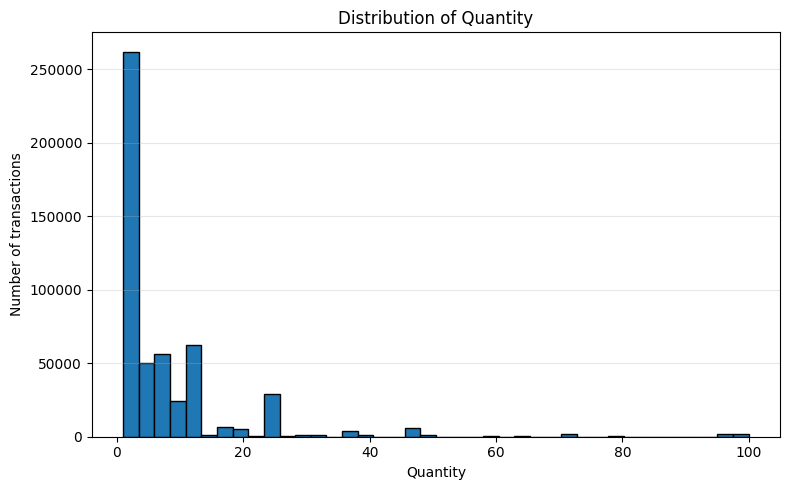

In [54]:
quantity = df['Quantity'].dropna()

limit = quantity.quantile(0.99)
quantity_clean = quantity[quantity <= limit]

plt.figure(figsize=(8,5))
plt.hist(quantity_clean, bins=40,edgecolor='black')
plt.title('Distribution of Quantity')
plt.xlabel('Quantity')
plt.ylabel('Number of transactions')

plt.grid(axis='y',alpha=0.3)
plt.tight_layout()
plt.show()

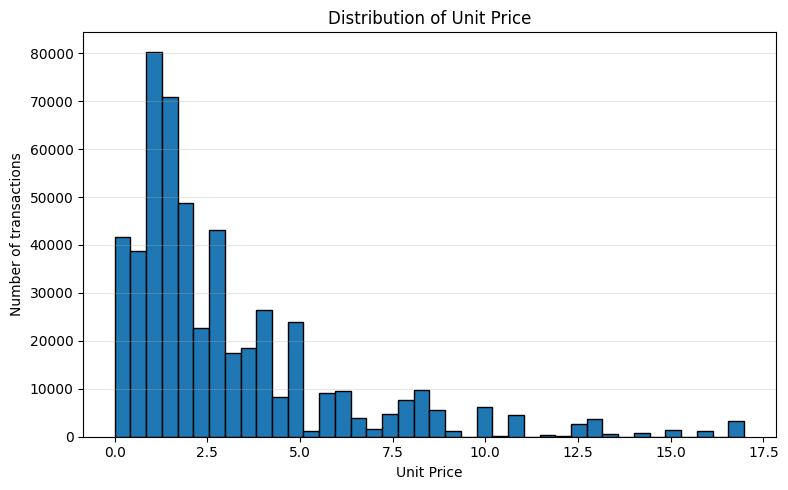

In [52]:
unit_price = df['UnitPrice'].dropna()

limit = unit_price.quantile(0.99)
unit_price_clean = unit_price[unit_price <= limit]

plt.figure(figsize=(8,5))
plt.hist(unit_price_clean, bins=40,edgecolor='black')
plt.title('Distribution of Unit Price')
plt.xlabel('Unit Price')
plt.ylabel('Number of transactions')

plt.grid(axis='y',alpha=0.3)
plt.tight_layout()
plt.show()

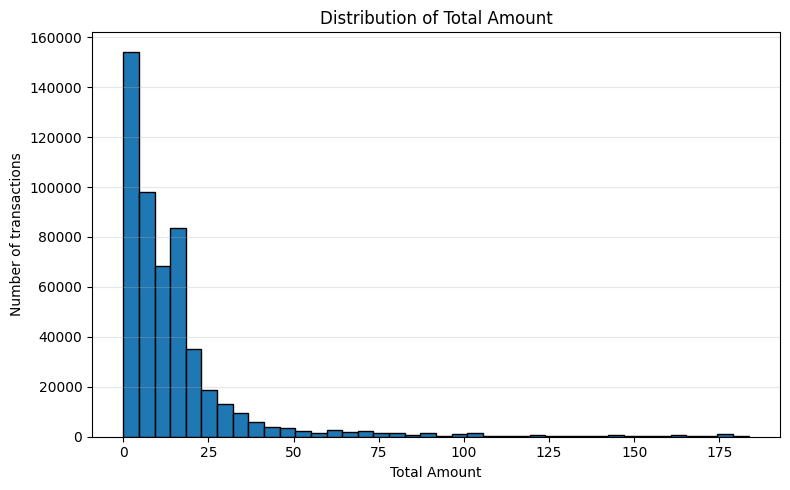

In [53]:
total_amount = df['TotalAmount'].dropna()

limit = total_amount.quantile(0.99)
total_amount_clean = total_amount[total_amount <= limit]

plt.figure(figsize=(8,5))
plt.hist(total_amount_clean, bins=40,edgecolor='black')
plt.title('Distribution of Total Amount')
plt.xlabel('Total Amount')
plt.ylabel('Number of transactions')

plt.grid(axis='y',alpha=0.3)
plt.tight_layout()
plt.show()

### Observation

The three histograms show the distribution of Quentity, UnitPrice and TotalAmount in the dataset. The charts are displayed up to the 99th percentile and provide a clear view of the main distribution.

The Quantity distribution shows that most transactions have relatively small quantities, other hand small number of transactions have very high quantities.

The UnitPrice distributions shows a similar pattern. Most products have relatively low unit prices, while a small number of products have much higher prices.

The TotalAmount distribution is also concentrated around lower values, with some transactions having much higher total amounts. This indicates that most purchases have relatively small total values, while some transaction have higher values.


## Outlier Analysis

In this Section we will identify  unusual values in the numerical variables.

Box plot will be used to examine  Quantity, UnitPrice and TotalAmount and it will help us identify values that are much higher or lower than most transactions. 

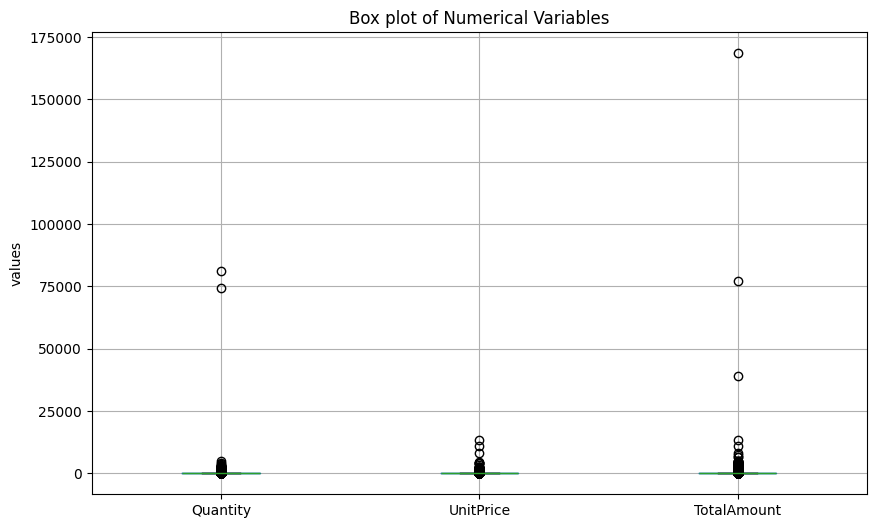

In [37]:
 # Create box plots for the main numerical variables 

plt.figure(figsize=(10,6))

df[['Quantity', 'UnitPrice', 'TotalAmount']].boxplot()

plt.title("Box plot of Numerical Variables")
plt.ylabel("values")

plt.show()

### Observation

The box plot shows that all three numerical variables contain some unusual values.

For Quantity most values group near the lower part of the chart while few values are higher. This point may be outlier.

For UnitPrice, most values are also lower range while some group shows separately higher values from the main group.

For TotalAmount, most values are at the lower level but some higher values can be seen. These are represent unusual large transaction amounts.

These unusual values may be real transactions, so they will not be removed automaticlly.They will be consider in the later analysis.



# Multivariate Analysis

In this section, we will examine the relationship between the numerical variables. We will compare 

Quantity, UnitPrice and TotalAmount to understand that how these variables are related to each other.

Scatter plot will help us to identify pattern and relationships between the variables.



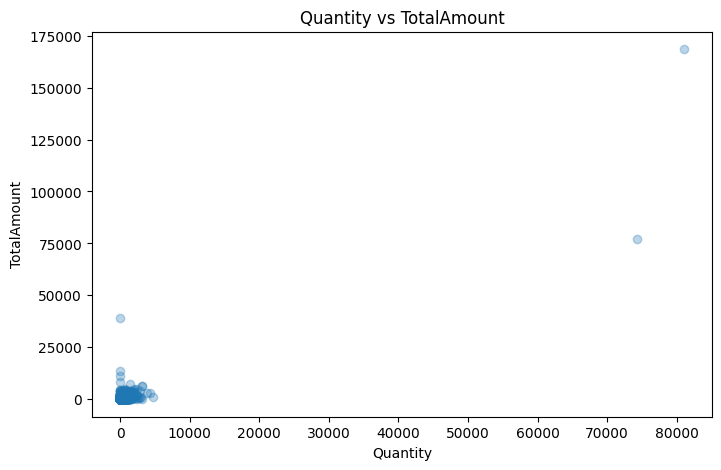

In [38]:
plt.figure(figsize=(8,5))

plt.scatter(df['Quantity'],
            df['TotalAmount'], alpha=0.3)

plt.title("Quantity vs TotalAmount")
plt.xlabel("Quantity")
plt.ylabel("TotalAmount")

plt.show()

## Observation

The scatter plot show that relationship between Quantity and TotalAmount.

Most transaction are at lower Quantity and lower TotalAmount values. Also some transaction have higher values than the main group.

This shows that higher quantity can lead to higher total amounts. The unusual high values may be outlier.

## Correlation Analysis

We will check the relationship between the numerical variables.

Correlation help us to understand that how strong their relationship.

We will calculate the correlation between Quantity, UnitPrice and TotalAmount, display the result using heatmap.

In [39]:
# correlation between numerical variables

corr = df[['Quantity', 'UnitPrice', 'TotalAmount']].corr()
print("Correlation Matrix:")
print(corr)

Correlation Matrix:
             Quantity  UnitPrice  TotalAmount
Quantity     1.000000  -0.003788     0.907402
UnitPrice   -0.003788   1.000000     0.137381
TotalAmount  0.907402   0.137381     1.000000


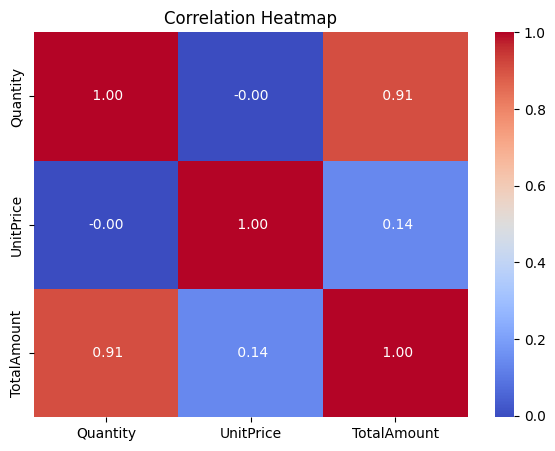

In [40]:
plt.figure(figsize=(7,5))
sns.heatmap(corr, annot=True,
cmap='coolwarm', fmt=' .2f')

plt.title("Correlation Heatmap")
plt.show()


### Observation
The correlation matrix and heatmap show the relationships between Quantity, UnitPrice and TotalAmount.

Quantity and totalAmount have strong positive correlation of about 0.91

UnitPrice and TotalAmount have weak positive correlation of about 0.14

Quantity and UnitPrice have almost no correlation with value 0

Overall Quantity has the strogest relation with Totalamount.

##  Timebased Analysis

In this section we will analyze sales over the time.

It will help to understand that how transactions and total sales change across different dates.

In [41]:
df.columns

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country', 'TotalAmount'],
      dtype='object')

In [42]:
# Concert InvoiceDate to datetime format
df['InvoiceDate'] = pd.to_datetime(
    df['InvoiceDate'],
    errors='coerce')

# Check the result

print(df['InvoiceDate'].dtype)

datetime64[ns]


---

In [43]:
# Calculate monthly total sales

monthly_sales = df.groupby(
df['InvoiceDate'].dt.to_period('M')
)['TotalAmount'].sum()

print(monthly_sales)

InvoiceDate
2010-12     821452.730
2011-01     689811.610
2011-02     522545.560
2011-03     716215.260
2011-04     536968.491
2011-05     769296.610
2011-06     760547.010
2011-07     718076.121
2011-08     757841.380
2011-09    1056435.192
2011-10    1151263.730
2011-11    1503866.780
2011-12     637790.330
Freq: M, Name: TotalAmount, dtype: float64


### Observasion

The monthly sales values change across different months.

The highest sales were recorded in November 2011, otherside the lowest sales were recorded in February 2011

Overall the result show that sales vary over time.

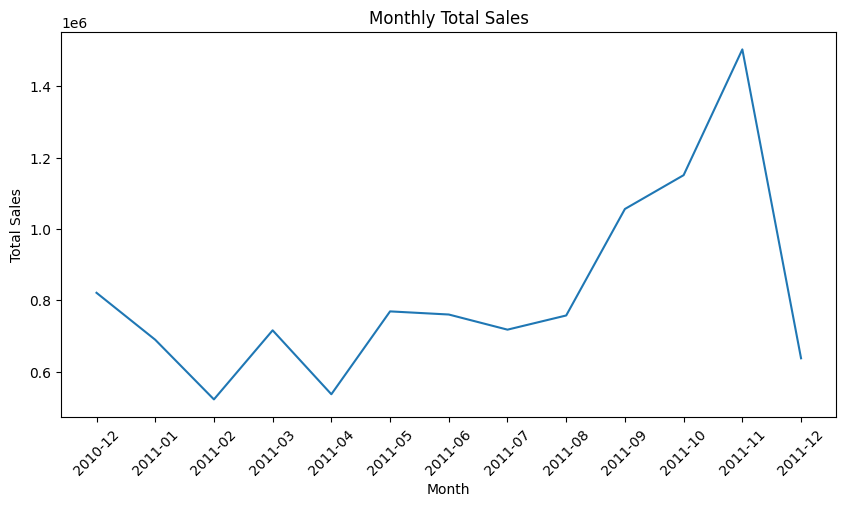

In [44]:
plt.figure(figsize=(10,5))

plt.plot(monthly_sales.index.astype(str),monthly_sales.values)
plt.title("Monthly Total Sales")
plt.xlabel("Month")
plt.ylabel("Total Sales")

plt.xticks(rotation=45)

plt.show()

### Observation

The line chart shows that monthly total sales changed over time.

Sales decreased from December 2010 to February 2011.
Sales increased and decreased slightly during the middle month of 2011.
Inshort, the chart shows variation in monthly sales throughout the period.

## Customer Analysis

In this section, we will analyse customer purchasing behaviuor.

The analysis will focus on the number of unique customers, transaction frequancy and spending time by them.

In [45]:
# Number of unique customers
unique_customers = df['CustomerID'].nunique()

print('Number of unique customers:',unique_customers)


Number of unique customers: 4338


In [46]:
# Total spending time by customers

customer_spending = (
df.groupby('CustomerID')
['TotalAmount']
.sum()
.sort_values(ascending=False)
)

print(customer_spending.head(10))

CustomerID
15287    1755388.60
14646     280206.02
18102     259657.30
17450     194390.79
16446     168472.50
14911     143711.17
12415     124914.53
14156     117210.08
17511      91062.38
16029      80850.84
Name: TotalAmount, dtype: float64


### Observation

Analysis shows that customers have different level of purchasing.

The top customer contribute a large amount of total sales compare with other customers. This shows that small group of customers may contribute overall revenue.

# Product Analysis

Now we analyse product level purchasing pattern.

This time analysis will focus on the most frequently purchased products and generating the highest total sales.

In [47]:
# Top 10 products sold
top_product = (
    df.groupby('Description')
    ['Quantity']
    .sum()
    .sort_values(ascending=False)
)

print(top_product.head(10))

Description
PAPER CRAFT , LITTLE BIRDIE           80995
MEDIUM CERAMIC TOP STORAGE JAR        78033
WORLD WAR 2 GLIDERS ASSTD DESIGNS     54951
JUMBO BAG RED RETROSPOT               48371
WHITE HANGING HEART T-LIGHT HOLDER    37872
POPCORN HOLDER                        36749
PACK OF 72 RETROSPOT CAKE CASES       36396
ASSORTED COLOUR BIRD ORNAMENT         36362
RABBIT NIGHT LIGHT                    30739
MINI PAINT SET VINTAGE                26633
Name: Quantity, dtype: int64


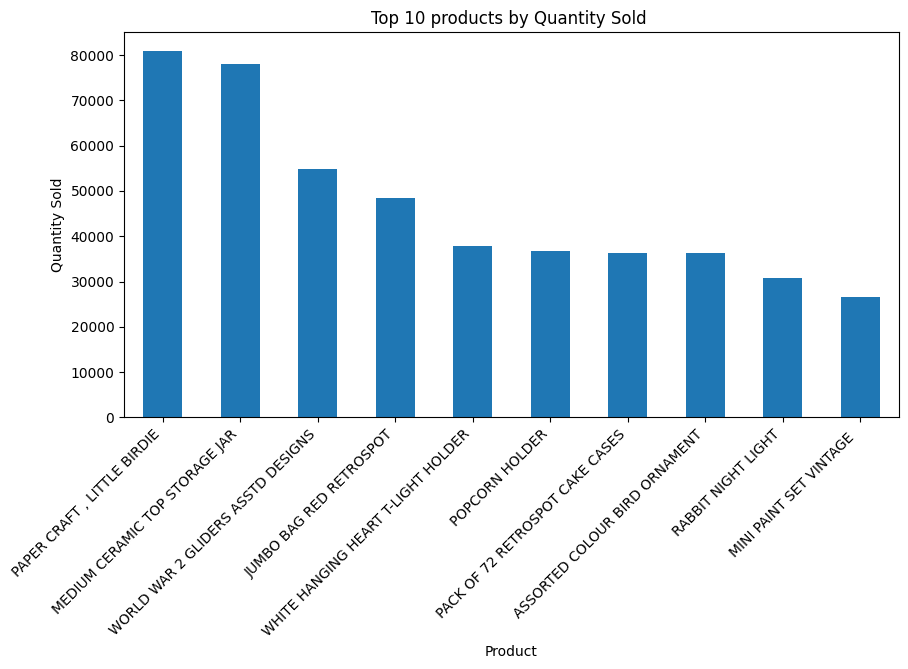

In [48]:
# Bar chart for top 10 product
top_product.head(10).plot(kind='bar',figsize=(10,5))
plt.title('Top 10 products by Quantity Sold ')
plt.xlabel('Product')
plt.ylabel('Quantity Sold')
plt.xticks(rotation=45, ha='right')

plt.show()

### Observation
PAPER CRAFT,LITTLE BIRDIE is the most purchse product with 80995 units sold.

MEDIUM CERAMIC TOP STORAGE JAR is the second purchsed product, with 78033. 

Other top products also have high quantities sold that showing demand for these items.

Overall the result shoews that samll group of products accounts for a large volume of purchases.

## Geographical Analysis
Now we will analyze sales performance across different countries.

This time analysis will focus on total sales and tarnsaction activity by country to identify the key geographical markets.


In [49]:
country_sales = (
    df.groupby('Country')
    ['TotalAmount']
    .sum()
    .sort_values(ascending=False)
)

print(country_sales.head(10))

Country
United Kingdom    9001744.094
Netherlands        285446.340
EIRE               283140.520
Germany            228678.400
France             209625.370
Australia          138453.810
Spain               61558.560
Switzerland         57067.600
Belgium             41196.340
Sweden              38367.830
Name: TotalAmount, dtype: float64


### Observation

The United Kingdom has the highest total sales by a large margin.

The Netherlands and EIRE are the next highest-selling countries.

Sales are mainly focus on few countries with the UK being the top market.

## Hypothesis/Statistical Analysis

In this section we will focus on statistically test relationships and differences identify during the exploratory analysis

### Hypothesis 1

We will test  hypothesis using satatistical analysis.

**Null Hypothesis (H0):** There is no significant relationship between Quantity and TotalAmount.

**Alternative Hypothesis (H1):** There is a significant relationship between Quantity and TotalAmount.

**Significance Level:** 5% (a = 0.05)

In [50]:
from scipy.stats import pearsonr

correlation, p_value = pearsonr(
    df['Quantity'],
    df['TotalAmount']
)
print("Correlation:", correlation)
print("p_value:", p_value)

Correlation: 0.9074018676034863
p_value: 0.0


### Statistical Test Result

The test result shows strong positive relationship between Quantity and TotalAmount with 0.9074.

The p-value is 0.0 which is less than 0.05.

Therefore, we can reject the null Hypothesis (H0) and accept the alternative Hypothesis (H1).

It shows that there is a statistically significant relationship between TotalAmount and Quantity.



# Key Finding
This dataset contains 4,338 unique customers.
Monthly sales raise and fall over the time, some time sales increasing strongly towards the end of 2011.
Some products sold in large number.
The United Kingdom is the top performing country in terms of total sales.
Quantity and TotalAmount have strong positive relationship.
The Hypothesis test shows that this relationship is statisticlly significant.


# Final Analysis

The analysis provided a better understanding of the online retail transaction data.
The result shows that sales change over the time with some months have higher sales than others. The United Kingdom is the leading country in term of total sales.
The customer analysis also shows that different level of purchasing activity. The correlation analysis found a strong positive relationship between Quantity and TotalAmount.
Overll, this analysis shows that important pattern in sales, customer, product,and geographical market.


# Business Insights
The analysis provides some useful business insights:
* The United Kingdom is the leading market and contributes the highest total sales.
* Small number of products have selling more. So these products are more important for the business.
* Monthly sales change over the time which can help to identify  strong and weak sales time.
* Some customers are contribute more to total spending than other.
* Quantity has a strong positive relationship with Totalamount. It selling more units generally results in higher transaction amounts.



---

# Conclusion
The EDA helped identify important pattern and relationships in the online retail dataset.
The analysis showed differences in customer behaviour, product demand, monthly sales and sales across countries. The statistical test also confirmed a significant positive relationship between Quantity and TotalAmount.
The analysis provides useful information that can support better future sales planning, product management and customer-focused decisions. 




# Recommendations

* Keep popular products instock to meet customers demand.
* Focus marketing activities on the leading markets while exploring opportunities in other countries.
* Use monthly sales trends to plan stock and promotions during high and low sales periods.
* Indentify high value customers and encourage them to repeat purchses.
* Use the findings from this analysis to support future business decisions and predictive machine learning models. 

# Next Step
The next step is to create the Data Visualizations.

The visualizations will present main findings from the EDA in a clear and easy to understand way. This visualizations will include sales trends, top products, customer spending and relationships between important variables.
